In [1]:
import xarray as xr
from datetime import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats


In [2]:
ERA5_FWI_inputs = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/FWI_inputs.nc")
ERA5_FWI_inputs['longitude'] = np.array([val+360 for val in ERA5_FWI_inputs.longitude])


In [3]:
their_era5_FWI = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/FWI/FWI_1980_2020.nc")

my_era5_FWI = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5_FWI.nc")
my_era5_FWI['longitude'] = np.array([val+360 for val in my_era5_FWI.longitude])
their_era5_FWI = their_era5_FWI.sel(Latitude=slice(my_era5_FWI.latitude[0].data,my_era5_FWI.latitude[-1].data),Longitude=slice(my_era5_FWI.longitude[0].data,my_era5_FWI.longitude[-1].data))
my_era5_FWI = my_era5_FWI.sel(time=slice(their_era5_FWI.Time[0],their_era5_FWI.Time[-1]))

my_era5_FWI = my_era5_FWI.rename({'latitude':'Latitude','longitude':'Longitude','time':'Time'})

Text(0.5, 1.0, 'THIER ERA5 FWI')

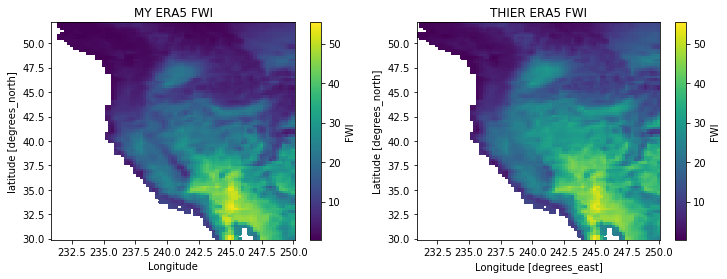

In [4]:
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

my_era5_FWI.FWI.mean('Time').plot(ax=axs[0])
their_era5_FWI.FWI.mean('Time').plot(ax=axs[1])

axs[0].set_title("MY ERA5 FWI")
axs[1].set_title("THIER ERA5 FWI")

#plt.savefig("FWI_compare.png",dpi=300)

Text(0.5, 1.0, 'THIER ERA5 FWI TREND')

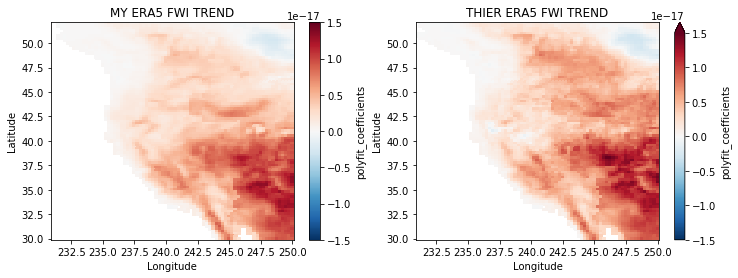

In [5]:
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

my_poly_fit = my_era5_FWI.FWI.polyfit(dim='Time',deg=1,skipna=True)
their_poly_fit = their_era5_FWI.FWI.polyfit(dim='Time',deg=1,skipna=True)

my_poly_fit.sel(degree=1).polyfit_coefficients.plot(ax=axs[0],vmin=-1.5e-17,vmax=1.5e-17,cmap='RdBu_r')
their_poly_fit.sel(degree=1).polyfit_coefficients.plot(ax=axs[1],vmin=-1.5e-17,vmax=1.5e-17,cmap='RdBu_r')

axs[0].set_title("MY ERA5 FWI TREND")
axs[1].set_title("THIER ERA5 FWI TREND")

#plt.savefig("FWI_compare.png",dpi=300)

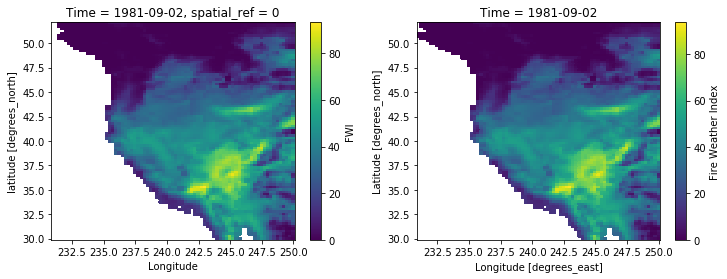

In [6]:
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

my_era5_FWI.FWI.isel(Time=610).plot(ax=axs[0])
their_era5_FWI.FWI.isel(Time=610).plot(ax=axs[1])

#axs[0].set_title("MY ERA5 FWI")
#axs[1].set_title("THIER ERA5 FWI")

#plt.savefig("FWI_compare.png",dpi=300)